In [1]:
import pandas as pd

In [2]:
a = pd.read_csv("insurance_data.csv")
a

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


In [3]:
a.columns[a.isna().any()]

Index([], dtype='object')

In [4]:
a.describe()

,age,bought_insurance
count,27.000000,27.000000
mean,39.666667,0.518519
std,15.745573,0.509175
min,18.000000,0.000000
25%,25.000000,0.000000
50%,45.000000,1.000000
75%,54.500000,1.000000
max,62.000000,1.000000


In [5]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               27 non-null     int64
 1   bought_insurance  27 non-null     int64
dtypes: int64(2)
memory usage: 564.0 bytes


In [15]:
#future selection
x=a[["age"]]
y=a["bought_insurance"]
x
y
import numpy as np
x=np.array(x).reshape(-1,1)
x
y=np.array(y)
y

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0])

In [16]:
import sklearn

In [17]:
from sklearn.model_selection import train_test_split


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_test

array([[62],
       [29],
       [61],
       [26],
       [22],
       [28],
       [25],
       [58],
       [27]])

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred=lr.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [22]:
x_test

array([[62],
       [29],
       [61],
       [26],
       [22],
       [28],
       [25],
       [58],
       [27]])

In [23]:

y_test

array([1, 0, 1, 0, 0, 0, 1, 1, 0])

In [24]:
from sklearn.metrics import r2_score

In [25]:
r2_score(y_test,y_pred)

0.55

In [26]:
import numpy as np
sorted_idx = np.argsort(x_train)
x_s= x_train[sorted_idx]
y_s= y_pred[sorted_idx]

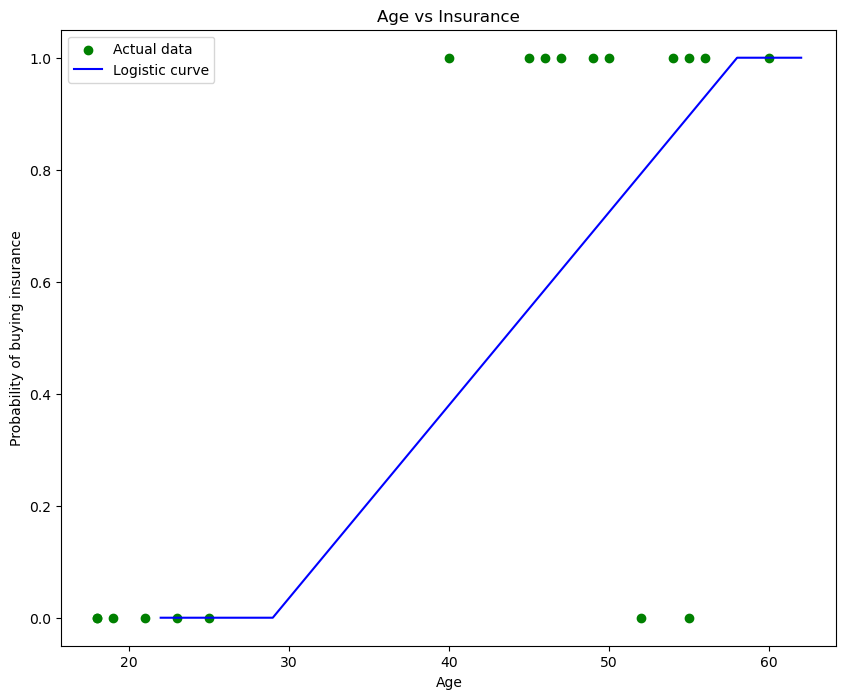

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Sort x_test and y_pred together
sorted_idx = np.argsort(x_test.flatten())
x_test_sorted = x_test.flatten()[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,8))
plt.scatter(x_train, y_train, color="green", label="Actual data")
plt.plot(x_test_sorted, y_pred_sorted, color="blue", label="Logistic curve")
plt.title("Age vs Insurance")
plt.xlabel("Age")
plt.ylabel("Probability of buying insurance")
plt.legend()
plt.show()